# Online Retail Dataset - Preprocessing and EDA

---

This notebook performs an initial **Exploratory Data Analysis (EDA)** on the *Online Retail* dataset, a transactional dataset containing all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based online retail company.

### Objectives

1. **Missing values** — identify columns with nulls, focusing on `CustomerID`.
2. **Numerical analysis** — detect negative values (returns) and outliers in `Quantity` and `UnitPrice`.
3. **Time range** — summarise the period covered by `InvoiceDate`.
4. **Data cleaning** — remove duplicates, rows with missing `CustomerID`, cancelled orders, and non-positive prices.

---

### Dataset columns

| Column | Description |
|---|---|
| `InvoiceNo` | Invoice number. Starts with 'C' if cancelled. |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Units per transaction (negative = return) |
| `InvoiceDate` | Date and time of transaction |
| `UnitPrice` | Price per unit in GBP |
| `CustomerID` | Unique customer identifier |
| `Country` | Customer's country |

## 0. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA_PATH = 'Online Retail.xlsx'

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# Load the dataset — openpyxl is required for .xlsx files
df_raw = pd.read_excel(DATA_PATH, engine='openpyxl')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape: 541,909 rows × 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 1. Initial Overview

In [3]:
# Data types 
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [7]:
# Basic descriptive statistics for numerical columns only
# Note: include='number' excludes datetime columns (InvoiceDate) whose
# Timestamps cannot be cast to float by the Styler background_gradient.
df_raw.describe(include='number').T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'min', 'max'])

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.000000,9.552250,218.081158,-80995.000000,1.000000,3.000000,10.000000,80995.000000
UnitPrice,541909.000000,4.611114,96.759853,-11062.060000,1.250000,2.080000,4.130000,38970.000000
CustomerID,406829.000000,15287.690570,1713.600303,12346.000000,13953.000000,15152.000000,16791.000000,18287.000000


## 2. Missing Values Analysis

In [4]:
# Count and percentage of missing values per column
missing = (
    df_raw.isnull()
    .sum()
    .rename('missing_count')
    .to_frame()
)
missing['missing_pct'] = (missing['missing_count'] / len(df_raw) * 100).round(2)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print('=== Columns with missing values ===')
display(missing.style.format({'missing_pct': '{:.2f}%'}).background_gradient(cmap='Reds', subset=['missing_pct']))

# Highlight CustomerID specifically
n_missing_cid = df_raw['CustomerID'].isnull().sum()
pct_missing_cid = n_missing_cid / len(df_raw) * 100
print(f"\n⚠️  CustomerID — {n_missing_cid:,} missing rows ({pct_missing_cid:.1f}% of dataset)")
print("    These rows CANNOT be attributed to a customer and will be excluded during cleaning.")

=== Columns with missing values ===


,missing_count,missing_pct
CustomerID,135080,24.93%
Description,1454,0.27%



⚠️  CustomerID — 135,080 missing rows (24.9% of dataset)
    These rows CANNOT be attributed to a customer and will be excluded during cleaning.


## 3. Quantity and UnitPrice — Outliers & Negative Values

In [5]:
# ── 3.1  Negative Quantity (returns / cancellations) ────────────────────────
neg_qty = df_raw[df_raw['Quantity'] < 0]
cancelled = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')]

print('=== Returns & Cancellation Signals ===')
print(f"  Rows with Quantity < 0  : {len(neg_qty):,}  ({len(neg_qty)/len(df_raw)*100:.2f}%)")
print(f"  Rows where InvoiceNo ~ 'C' : {len(cancelled):,}  ({len(cancelled)/len(df_raw)*100:.2f}%)")
print(f"  Min Quantity            : {df_raw['Quantity'].min():,}")
print(f"  Max Quantity            : {df_raw['Quantity'].max():,}")

# Show a few return records
print("\nSample return rows:")
neg_qty[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']].head(5)

=== Returns & Cancellation Signals ===
  Rows with Quantity < 0  : 10,624  (1.96%)
  Rows where InvoiceNo ~ 'C' : 9,288  (1.71%)
  Min Quantity            : -80,995
  Max Quantity            : 80,995

Sample return rows:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
141,C536379,D,Discount,-1,27.50,14527.0
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0


In [6]:
# ── 3.2  Negative / zero UnitPrice ──────────────────────────────────────────
non_pos_price = df_raw[df_raw['UnitPrice'] <= 0]

print('=== Non-positive UnitPrice ===')
print(f"  Rows with UnitPrice <= 0 : {len(non_pos_price):,}  ({len(non_pos_price)/len(df_raw)*100:.2f}%)")
print(f"  Min UnitPrice            : {df_raw['UnitPrice'].min():.4f}")
print(f"  Unique zero-price codes  : {df_raw.loc[df_raw['UnitPrice'] == 0, 'StockCode'].nunique()}")

print("\nSample zero/negative price rows:")
non_pos_price[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']].head(5)

=== Non-positive UnitPrice ===
  Rows with UnitPrice <= 0 : 2,517  (0.46%)
  Min UnitPrice            : -11062.0600
  Unique zero-price codes  : 1419

Sample zero/negative price rows:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
622,536414,22139,NaN,56,0.0,NaN
1970,536545,21134,NaN,1,0.0,NaN
1971,536546,22145,NaN,1,0.0,NaN
1972,536547,37509,NaN,1,0.0,NaN
1987,536549,85226A,NaN,1,0.0,NaN


In [7]:
# ── 3.3  Outlier detection using IQR ────────────────────────────────────────
def iqr_bounds(series):
    """Return (lower, upper) fence using 1.5 × IQR rule."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# Work on positive-quantity, positive-price rows for outlier detection
df_pos = df_raw[(df_raw['Quantity'] > 0) & (df_raw['UnitPrice'] > 0)].copy()

for col in ['Quantity', 'UnitPrice']:
    lo, hi = iqr_bounds(df_pos[col])
    outliers = df_pos[(df_pos[col] < lo) | (df_pos[col] > hi)]
    print(f"[{col}]  IQR fences: [{lo:.2f}, {hi:.2f}]")
    print(f"         Outlier rows : {len(outliers):,}  ({len(outliers)/len(df_pos)*100:.2f}%)\n")

[Quantity]  IQR fences: [-12.50, 23.50]
         Outlier rows : 56,363  (10.63%)

[UnitPrice]  IQR fences: [-3.07, 8.45]
         Outlier rows : 37,999  (7.17%)



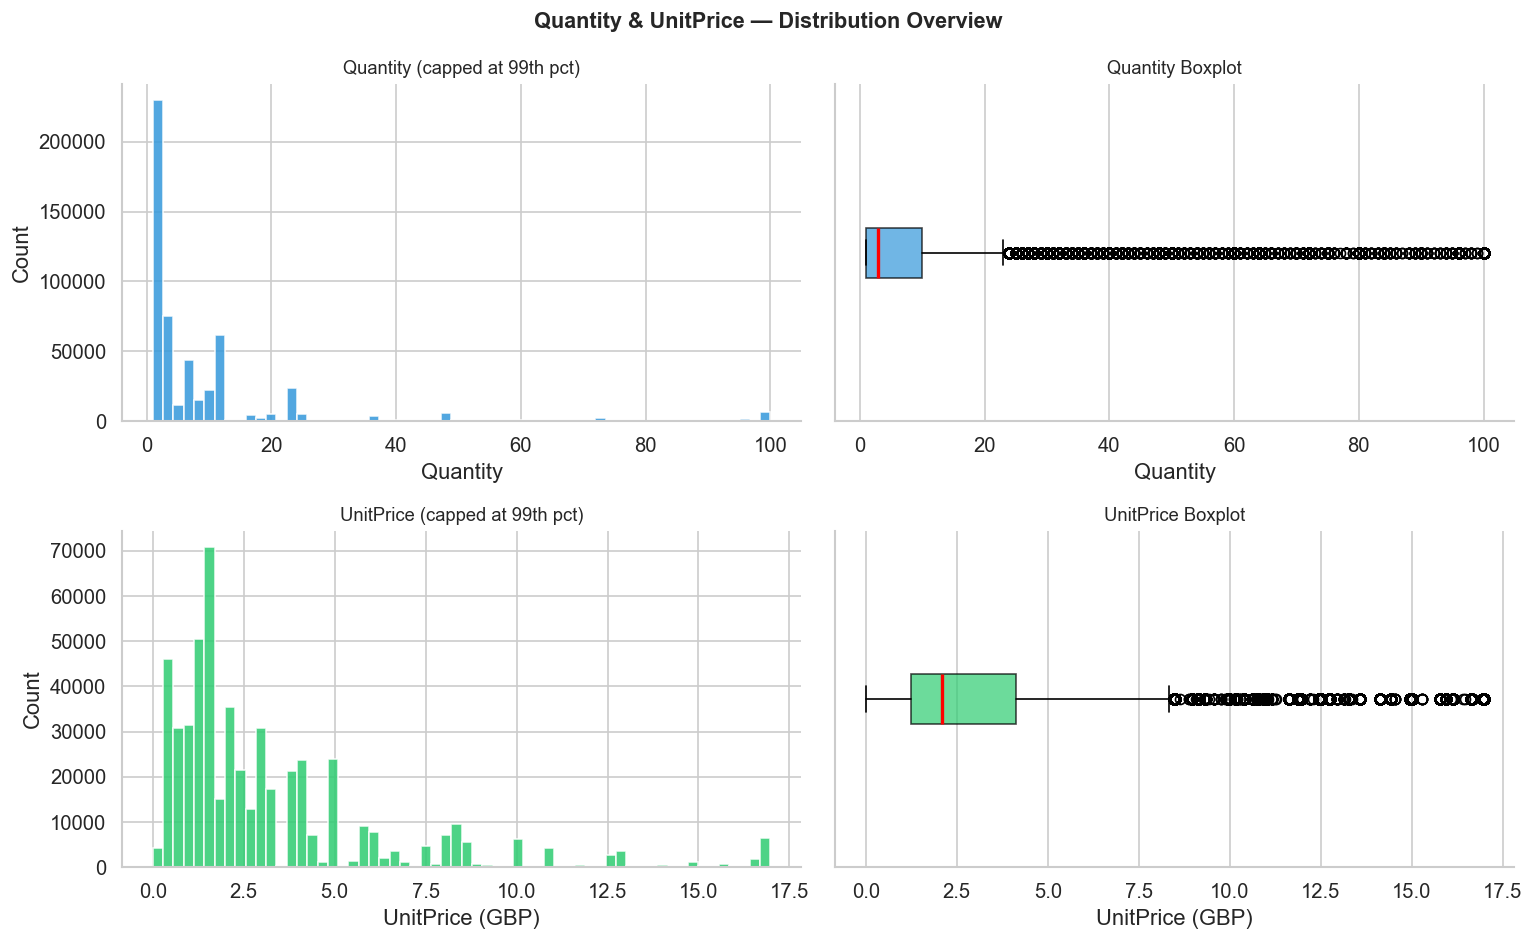

In [8]:
# ── 3.4  Visual distributions ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Quantity & UnitPrice — Distribution Overview', fontweight='bold', fontsize=13)

# Raw distributions (capped for readability)
cap_qty   = df_pos['Quantity'].clip(upper=df_pos['Quantity'].quantile(0.99))
cap_price = df_pos['UnitPrice'].clip(upper=df_pos['UnitPrice'].quantile(0.99))

# Histogram — Quantity
axes[0, 0].hist(cap_qty, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Quantity (capped at 99th pct)', fontsize=11)
axes[0, 0].set_xlabel('Quantity'); axes[0, 0].set_ylabel('Count')

# Boxplot — Quantity
axes[0, 1].boxplot(cap_qty, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Quantity Boxplot', fontsize=11)
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_yticks([])

# Histogram — UnitPrice
axes[1, 0].hist(cap_price, bins=60, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[1, 0].set_title('UnitPrice (capped at 99th pct)', fontsize=11)
axes[1, 0].set_xlabel('UnitPrice (GBP)'); axes[1, 0].set_ylabel('Count')

# Boxplot — UnitPrice
axes[1, 1].boxplot(cap_price, vert=False, patch_artist=True,
                   boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('UnitPrice Boxplot', fontsize=11)
axes[1, 1].set_xlabel('UnitPrice (GBP)')
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

## 4. Time Range Analysis

In [9]:
# Ensure InvoiceDate is datetime
df_raw['InvoiceDate'] = pd.to_datetime(df_raw['InvoiceDate'])

date_min = df_raw['InvoiceDate'].min()
date_max = df_raw['InvoiceDate'].max()
date_span = (date_max - date_min).days
n_months  = df_raw['InvoiceDate'].dt.to_period('M').nunique()

print('=== Time Coverage ===')
print(f"  Earliest transaction : {date_min.strftime('%d %b %Y %H:%M')}")
print(f"  Latest  transaction  : {date_max.strftime('%d %b %Y %H:%M')}")
print(f"  Span                 : {date_span} days  (~{date_span/30:.1f} months)")
print(f"  Calendar months      : {n_months}")

=== Time Coverage ===
  Earliest transaction : 01 Dec 2010 08:26
  Latest  transaction  : 09 Dec 2011 12:50
  Span                 : 373 days  (~12.4 months)
  Calendar months      : 13


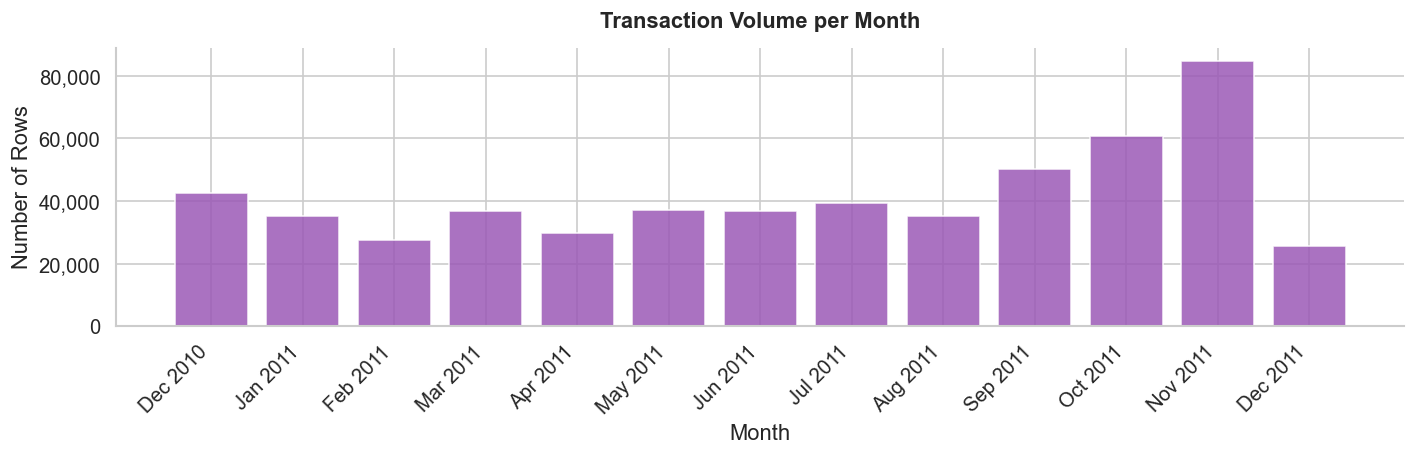

In [10]:
# Monthly transaction volume
monthly = (
    df_raw
    .set_index('InvoiceDate')
    .resample('ME')           # Month-End frequency
    .size()
    .rename('transactions')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['InvoiceDate'].dt.strftime('%b %Y'),
       monthly['transactions'],
       color='#9b59b6', edgecolor='white', alpha=0.85)

ax.set_title('Transaction Volume per Month', fontweight='bold', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Rows')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

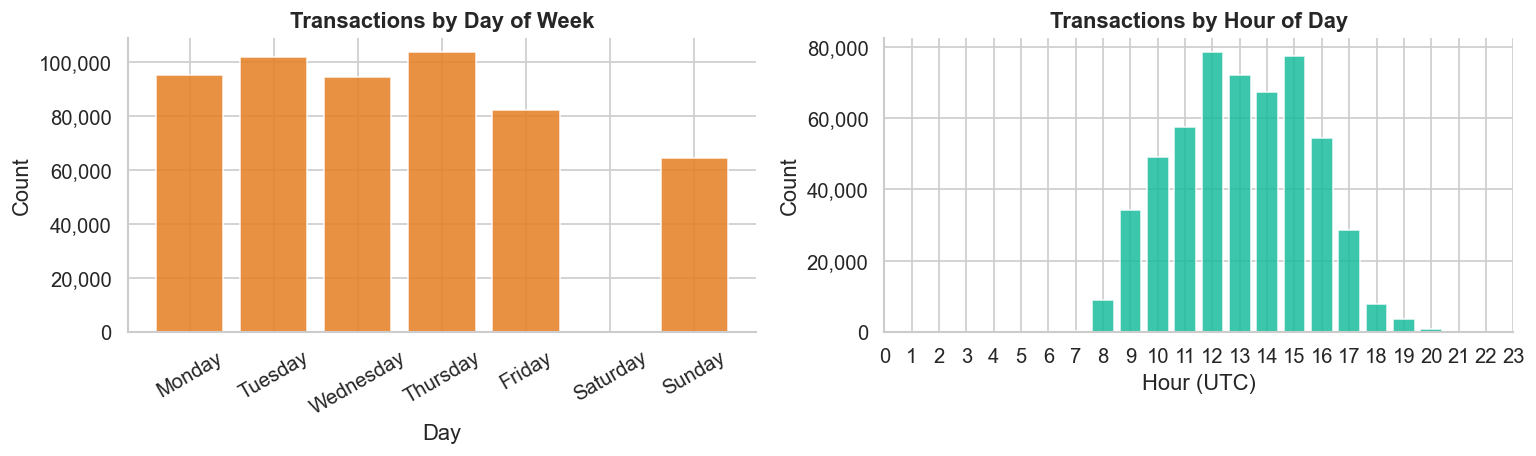

In [11]:
# Orders by day of week and hour of day
df_raw['DayOfWeek'] = df_raw['InvoiceDate'].dt.day_name()
df_raw['Hour']      = df_raw['InvoiceDate'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df_raw['DayOfWeek'].value_counts().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(day_counts.index, day_counts.values,
            color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].set_title('Transactions by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

hour_counts = df_raw['Hour'].value_counts().sort_index()
axes[1].bar(hour_counts.index, hour_counts.values,
            color='#1abc9c', edgecolor='white', alpha=0.85)
axes[1].set_title('Transactions by Hour of Day', fontweight='bold')
axes[1].set_xlabel('Hour (UTC)'); axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

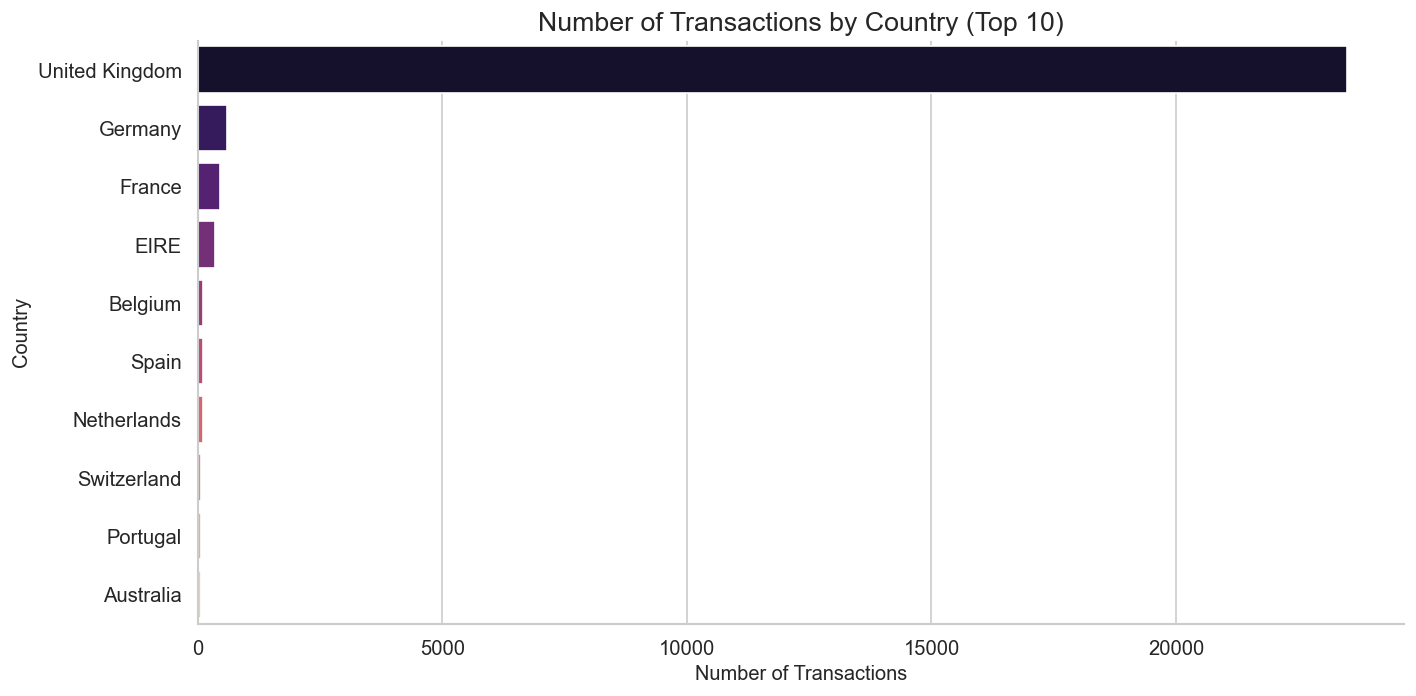

In [12]:
# Number of transactions (unique invoices) by country (Top 10)
trx_by_country = df_raw.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=trx_by_country.values, y=trx_by_country.index, hue=trx_by_country.index, palette='magma', legend=False)
plt.title('Number of Transactions by Country (Top 10)', fontsize=16)
plt.xlabel('Number of Transactions', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Data Cleaning

We apply the following filters **sequentially** and track how many rows each step removes:

| Step | Rule |
|------|------|
| 1 | Remove **duplicates** |
| 2 | Remove rows with **missing `CustomerID`** |
| 3 | Remove **cancelled orders** (`InvoiceNo` starts with 'C') |
| 4 | Remove rows where **`Quantity` ≤ 0** |
| 5 | Remove rows where **`UnitPrice` ≤ 0** |

In [13]:
cleaning_log = []

def log_step(label, df_before, df_after):
    removed = len(df_before) - len(df_after)
    cleaning_log.append({
        'Step': label,
        'Rows Before': len(df_before),
        'Rows Removed': removed,
        'Rows After': len(df_after),
        '% Removed': round(removed / len(df_before) * 100, 2),
    })
    return df_after

df = df_raw.copy()

# Step 1 — Duplicates
df_step = df.drop_duplicates()
df = log_step('1. Remove duplicates', df, df_step)

# Step 2 — Missing CustomerID
df_step = df.dropna(subset=['CustomerID'])
df = log_step('2. Drop missing CustomerID', df, df_step)

# Step 3 — Cancelled orders
df_step = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = log_step("3. Remove cancelled orders (InvoiceNo ~ 'C')", df, df_step)

# Step 4 — Non-positive Quantity
df_step = df[df['Quantity'] > 0]
df = log_step('4. Remove Quantity <= 0', df, df_step)

# Step 5 — Non-positive UnitPrice
df_step = df[df['UnitPrice'] > 0]
df = log_step('5. Remove UnitPrice <= 0', df, df_step)

# ── Cleaning summary table ───────────────────────────────────────────────────
log_df = pd.DataFrame(cleaning_log)
(
    log_df.style
    .format({'Rows Before': '{:,}', 'Rows Removed': '{:,}', 'Rows After': '{:,}', '% Removed': '{:.2f}%'})
    .background_gradient(cmap='Oranges', subset=['Rows Removed', '% Removed'])
    .set_caption('Cleaning Pipeline — Row Counts')
)

,Step,Rows Before,Rows Removed,Rows After,% Removed
0,1. Remove duplicates,"541,909","5,268","536,641",0.97%
1,2. Drop missing CustomerID,"536,641","135,037","401,604",25.16%
2,3. Remove cancelled orders (InvoiceNo ~ 'C'),"401,604","8,872","392,732",2.21%
3,4. Remove Quantity <= 0,"392,732",0,"392,732",0.00%
4,5. Remove UnitPrice <= 0,"392,732",40,"392,692",0.01%


In [14]:
# Final shape and reset index
df = df.reset_index(drop=True)
# Ensure CustomerID is integer
df['CustomerID'] = df['CustomerID'].astype(int)
# Drop helper columns added during analysis
df = df.drop(columns=['DayOfWeek', 'Hour'], errors='ignore')

original_rows = len(df_raw)
final_rows    = len(df)

print('=== Clean Dataset Summary ===')
print(f"  Original rows : {original_rows:,}")
print(f"  Final rows    : {final_rows:,}")
print(f"  Rows removed  : {original_rows - final_rows:,}  ({(original_rows - final_rows)/original_rows*100:.1f}%)")
print(f"  Unique customers : {df['CustomerID'].nunique():,}")
print(f"  Unique products  : {df['StockCode'].nunique():,}")
print(f"  Countries        : {df['Country'].nunique()}")
print()
df.head()

=== Clean Dataset Summary ===
  Original rows : 541,909
  Final rows    : 392,692
  Rows removed  : 149,217  (27.5%)
  Unique customers : 4,338
  Unique products  : 3,665
  Countries        : 37



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [15]:
# Verify no missing values remain
remaining_nulls = df.isnull().sum()
if remaining_nulls.sum() == 0:
    print('✅ No missing values in the clean dataset.')
else:
    print('⚠️  Remaining missing values:')
    print(remaining_nulls[remaining_nulls > 0])

✅ No missing values in the clean dataset.


In [16]:
# Cap Quantity to 99th percentile
qty_99th = df['Quantity'].quantile(0.99)
df['Quantity'] = df['Quantity'].clip(upper=qty_99th)

In [17]:
# Add derived column: Revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print('=== Clean Dataset — Descriptive Statistics ===')
df[['Quantity', 'UnitPrice', 'Revenue']].describe().T.style.background_gradient(cmap='Greens', subset=['mean', 'max'])

=== Clean Dataset — Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Quantity,392692.000000,11.022402,18.158425,1.000000,2.000000,6.000000,12.000000,120.000000
UnitPrice,392692.000000,3.125914,22.241836,0.001000,1.250000,1.950000,3.750000,8142.750000
Revenue,392692.000000,19.934160,76.138382,0.001000,4.950000,12.390000,19.800000,38970.000000


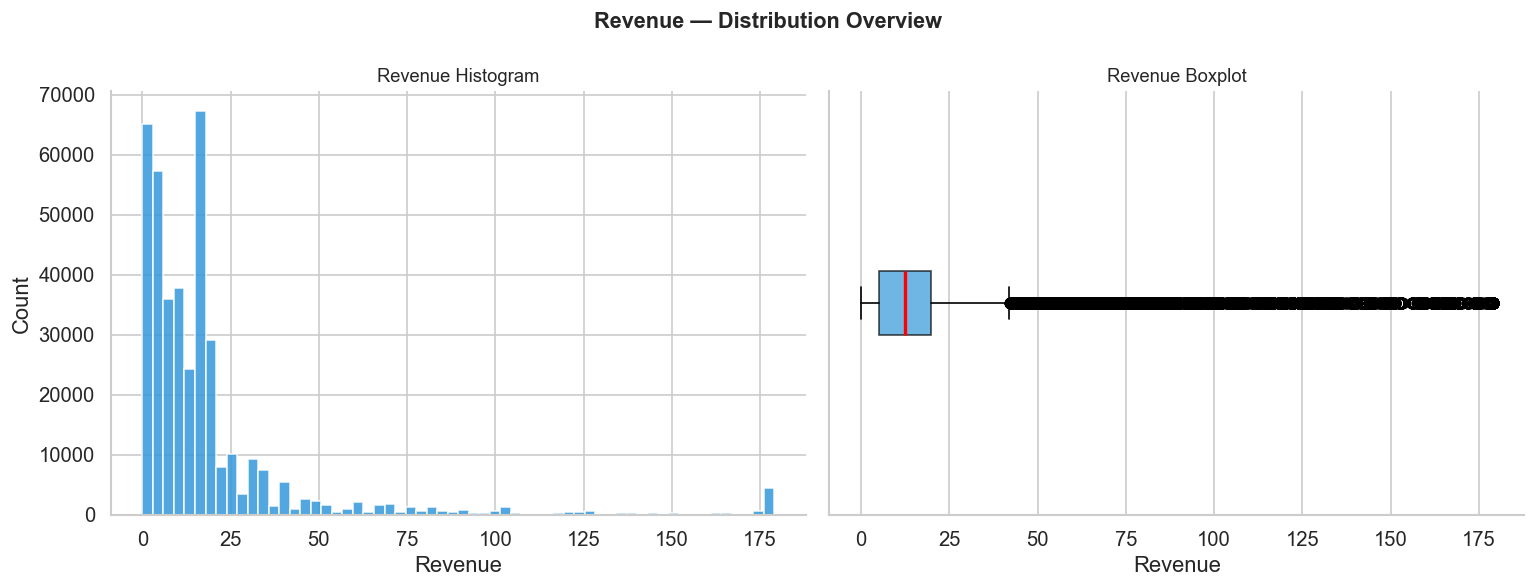

In [18]:
# ── Visual distributions: Revenue ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Revenue — Distribution Overview', fontweight='bold', fontsize=13)

# Drop missing values to prevent matplotlib errors
revenue_data = df['Revenue'].dropna()
revenue_data = revenue_data.clip(upper=revenue_data.quantile(0.99))

# Histogram — Revenue
axes[0].hist(revenue_data, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title('Revenue Histogram', fontsize=11)
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Count')

# Boxplot — Revenue
axes[1].boxplot(revenue_data, vert=False, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Revenue Boxplot', fontsize=11)
axes[1].set_xlabel('Revenue')
axes[1].set_yticks([])
plt.tight_layout()
plt.show()


In [19]:
# 5b. Filter for UK, Date <= 2011-11-30, and Cap Revenue Outliers
df = df[df['Country'] == 'United Kingdom']
df = df[df['InvoiceDate'] <= '2011-11-30 23:59:59'].copy()

print(f'Shape after final filtering: {df.shape[0]:,} rows × {df.shape[1]} columns')

Shape after final filtering: 333,680 rows × 9 columns


## 6. Summary & Next Steps

### Key Findings

| Finding | Detail |
|---|---|
| **Missing CustomerID** | ~25% of raw rows have no customer identifier |
| **Cancelled orders** | ~2% of rows are returns/cancellations (`InvoiceNo` ~ 'C') |
| **Outliers in Quantity** | Heavy positive skew; a handful of bulk orders inflate the tail |
| **Outliers in UnitPrice** | A few very high-priced items; some zero-price records (samples/errors) |
| **Time coverage** | Dec 2010 – Dec 2011 (≈13 months); Nov 2011 peaks before holidays |

### Cleaning Applied

- Duplicates removed  
- Rows without `CustomerID` excluded  
- Cancelled transactions excluded  
- Non-positive `Quantity` excluded  
- Non-positive `UnitPrice` excluded  
- `Quantity` capped at 99th percentile
- Only UK considered
- Data from Dec 2010 to Nov 2011